##Шаг 1: Инициализация и настройка среды:
**Задача 1:**
Обеспечить импорт всех необходимых библиотек (PyTorch, PyTorch Lightning, Pandas, NumPy, OpenCV, PIL), настройку воспроизводимости с помощью фиксации сида (seed_everything), и автоматическое определение используемого устройства (GPU или CPU).

In [ ]:
# ============================================================
# STEP 1. IMPORTS + REPRODUCIBILITY + DEVICE
# ============================================================

import argparse
import json
import os
import shutil
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from collections import OrderedDict
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
)
from PIL import Image
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
from tqdm import tqdm
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.io # Added to handle .mat annotation files
# Common
import random
import cv2 as cv
from IPython.display import clear_output as cls

# Data
import tensorflow as tf
from tqdm import tqdm 
import tensorflow.data as tfd

# Data Visualization
import matplotlib.pyplot as plt

PROJECT_ROOT_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
PROJECT_ROOT = next(
    (candidate for candidate in PROJECT_ROOT_CANDIDATES if (candidate / "src").exists() and (candidate / "configs").exists()),
    None,
 )
if PROJECT_ROOT is None:
    raise FileNotFoundError(f"Project root not found from notebook working directory: {Path.cwd().resolve()}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

base = PROJECT_ROOT
DATASET_DIR = PROJECT_ROOT / "stanford_dataset"
DEVKIT_DIR = PROJECT_ROOT / "devkit"
OUTPUT_DIR = PROJECT_ROOT / "output"

def seed_everything(seed: int = 42):
    """Фиксируем сид: torch + numpy + lightning."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    pl.seed_everything(seed, workers=True)

def get_device() -> torch.device:
    """Определяем устройство."""
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✅ Using CUDA: {torch.cuda.get_device_name(0)}")
        return device
    device = torch.device("cpu")
    print("✅ Using CPU")
    return device

DEVICE = get_device()
seed_everything(42)
print("✅ Project root:", PROJECT_ROOT)
print("✅ Dataset dir:", DATASET_DIR)

Global seed set to 42


✅ Using CPU


#Шаг 2 : Загрузка, распаковка и Label Engineering датасета:

**Задача 2.1:** Произвести загрузку датасета ashc004/stanford-car-dataset с Kaggle и его распаковку.

**Задача 2.2:**  Разработать функции infer_type_from_name для извлечения типа автомобиля и dominant_color_label_bgr_kmeans для определения цвета.

**Задача 2.3:** Определить списки классов TYPE_CLASSES, COLOR_CLASSES и их ID.

## Dataset Download And Setup



Use the project script for repeatable dataset download on the remote machine.


In [ ]:
# --- Legacy Colab download block ---

print("This notebook now uses the structured project workflow.")

print("For dataset download, run: python scripts/download_stanford_cars.py")

print("Or use the next notebook cell, which imports the shared helper from src.data.download.")


This notebook now uses the structured project workflow.
For dataset download, run: python /workspace/scripts/download_stanford_cars.py
Or use the next notebook cell, which imports the shared helper from src.data.download.


## Structured Project Download Step



This notebook imports the shared download helper from `src.data.download` instead of using inline shell logic.


In [ ]:
# ============================================================

# STEP 1. (OPTIONAL) KAGGLE DOWNLOAD

# ============================================================


from pathlib import Path

from src.data.download import download_kaggle_dataset

dataset_path = download_kaggle_dataset(
    dataset="ashc004/stanford-car-dataset",
    out_dir=PROJECT_ROOT / "stanford_dataset_raw",
    force=False,
 )

print("Dataset downloaded/extracted to:", dataset_path)


Dataset downloaded/extracted to: \workspace\stanford_dataset_raw\stanford-car-dataset


In [ ]:
# ============================================================

# STEP 2. LABEL ENGINEERING (TYPE / COLOR)

# ============================================================

import cv2
import numpy as np
from src.data.preprocessing import COLOR2ID, TYPE2ID, dominant_color_label_hsv_fast, infer_type_from_name
from src.models.multihead_classifier import COLOR_CLASSES, TYPE_CLASSES

##Additional K-Means for Color (Not Necessary)

In [ ]:
from src.data.preprocessing import dominant_color_label_bgr_kmeans

In [6]:
from src.data.preprocessing import add_type_color_labels


# Step 3: Structured Dataset Preparation



The repeatable preparation pipeline now lives in `src.data.preprocessing` and can also be run via `python /workspace/scripts/prepare_stanford_cars.py`.


## Пути к датасету 

In [ ]:
import os

from pathlib import Path

from PIL import Image, UnidentifiedImageError

import scipy.io as sio


# ============================================================

# STEP 3. DATASET PATH CHECK

# ============================================================


# Project layout:

# PROJECT_ROOT/stanford_dataset/cars_train

# PROJECT_ROOT/stanford_dataset/cars_test

# PROJECT_ROOT/devkit

base = PROJECT_ROOT

dataset_root = base / "stanford_dataset"

devkit_path = base / "devkit"

train_path = dataset_root / "cars_train"

test_path = dataset_root / "cars_test"

print("base    :", base)

print("dataset :", dataset_root.exists(), dataset_root)

print("devkit  :", devkit_path.exists(), devkit_path)

print("train   :", train_path.exists(), train_path)

print("test    :", test_path.exists(), test_path)

def scan_images(root_dir, exts=(".jpg", ".jpeg", ".png")):

    total = 0

    bad = []

    for p in root_dir.rglob("*"):

        if p.suffix.lower() in exts:

            total += 1

            try:

                with Image.open(p) as im:

                    im.verify()

            except (UnidentifiedImageError, OSError, IOError):

                bad.append(str(p))

    return total, bad

for directory in [train_path, test_path]:

    if not directory.exists():

        print("Не найден:", directory)

        continue

    total, bad = scan_images(directory)

    print(f"{directory.name}: total={total}, corrupted={len(bad)}")

    if bad:

        print("Первый битый:", bad[0])


base    : C:\Users\zhany\Downloads\workspace_stanford
dataset : True C:\Users\zhany\Downloads\workspace_stanford\stanford_dataset
devkit  : True C:\Users\zhany\Downloads\workspace_stanford\devkit
train   : False C:\Users\zhany\Downloads\workspace_stanford\stanford_dataset\cars_train
test    : False C:\Users\zhany\Downloads\workspace_stanford\stanford_dataset\cars_test
Не найден: C:\Users\zhany\Downloads\workspace_stanford\stanford_dataset\cars_train
Не найден: C:\Users\zhany\Downloads\workspace_stanford\stanford_dataset\cars_test


In [11]:
import os

print("Devkit path:", devkit_path)
print(os.listdir(devkit_path))

Devkit path: /workspace/devkit
['eval_train.m', 'README.txt', 'train_perfect_preds.txt', 'cars_train_annos.mat', 'cars_test_annos.mat', 'cars_meta.mat']


In [ ]:
import os
import scipy.io as sio

# Define the path to the devkit (local download)
devkit_path = base / "devkit"

# Let's verify the content of the devkit directory
print(f"Contents of {devkit_path}:")
if os.path.exists(devkit_path):
    for item in os.listdir(devkit_path):
        print(f"- {item}")
else:
    print(f"Directory {devkit_path} does not exist.")

# Load the annotation files
annos_train = sio.loadmat(os.path.join(devkit_path, "cars_train_annos.mat"))["annotations"][0]
annos_test = sio.loadmat(os.path.join(devkit_path, "cars_test_annos.mat"))["annotations"][0]
meta = sio.loadmat(os.path.join(devkit_path, "cars_meta.mat"))["class_names"][0]

print("Number of classes:", len(meta))

In [12]:
#Что реально внутри твоих .mat файлов
import scipy.io as sio
mat = sio.loadmat(os.path.join(devkit_path, "cars_train_annos.mat"))
print("Dtype of first annotation:", mat['annotations'][0][0].dtype)
print("Shape of annotations array:", mat['annotations'].shape)
print("Keys in mat file:", list(mat.keys()))

Dtype of first annotation: [('bbox_x1', 'O'), ('bbox_y1', 'O'), ('bbox_x2', 'O'), ('bbox_y2', 'O'), ('class', 'O'), ('fname', 'O')]
Shape of annotations array: (1, 8144)
Keys in mat file: ['__header__', '__version__', '__globals__', 'annotations']


In [ ]:
# Dataset preparation logic was moved to src.data.preprocessing

print("Use the structured pipeline in the next cell or run:")

print("python scripts/prepare_stanford_cars.py")


Use the structured pipeline in the next cell or run:
python /workspace/scripts/prepare_stanford_cars.py


In [ ]:
from pathlib import Path

from src.data.preprocessing import prepare_cropped_dataset

base = PROJECT_ROOT

dataset_root = base / "stanford_dataset"

cropped_dir = dataset_root / "cars_cropped"

csv_out = dataset_root / "cars_bbox_cropped.csv"

df = prepare_cropped_dataset(
    dataset_root=dataset_root,
    cropped_dir=cropped_dir,
    csv_path=csv_out,
    use_kmeans=False,
    pad=0.0,
    split_strategy="official",
    random_state=42,
 )

print(len(df), "cropped images with bbox saved to", cropped_dir)

print("Saved CSV:", csv_out)

print(df.head())


##Задача 4: Разведочный анализ данных (EDA):

**Задача 4.1: Проанализировать статистику датасета и дисбаланс классов**
Создайте анализ, показывающий:

* Распределение атрибутов (столбчатые диаграммы)
* Соотношения баланса классов, визуализацию распределения классов
* Показ примеров изображений для каждой комбинации с их метками
* Aнализ разрешений изображений

**Включить: общий обзор датасета**
Выполнить функцию run_eda для генерации статистических отчетов и визуализаций. , анализ и,  изображений.

##Обзор датасета и статистика (Dataset Overview and Statistics)
**Подзадача:**
Сообщить общее количество изображений, количество уникальных классов, а также общую статистику по датасету.

In [ ]:
# Dataset overview (robust for both stanford_cars.csv and cars_bbox_cropped.csv)

# ============================================================

# STEP 4A. DATASET OVERVIEW REPORT

# Read prepared CSV and print general dataset statistics

# ============================================================

from pathlib import Path

base = PROJECT_ROOT

candidate_csvs = [
    base / "stanford_dataset" / "cars_bbox_cropped.csv",
    base / "stanford_dataset" / "stanford_cars.csv",
    base / "data" / "cars_bbox_cropped.csv",
    base / "data" / "stanford_cars.csv",
    base / "cars_bbox_cropped.csv",
    base / "stanford_cars.csv",
    Path("stanford_dataset/cars_bbox_cropped.csv"),
    Path("stanford_dataset/stanford_cars.csv"),
    Path("data/cars_bbox_cropped.csv"),
    Path("data/stanford_cars.csv"),
]

csv_path = next((p for p in candidate_csvs if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError("CSV not found. Expected one of: stanford_dataset/cars_bbox_cropped.csv or stanford_dataset/stanford_cars.csv")

try:
    display_csv_path = csv_path.relative_to(base.resolve())
except ValueError:
    display_csv_path = csv_path

print("Workspace root:", base)

print("Using CSV:", display_csv_path)

df = pd.read_csv(csv_path)

print("Columns:", list(df.columns))

train_df = df[df["split"] == "train"].copy() if "split" in df.columns else df.copy()

test_df = df[df["split"] == "test"].copy() if "split" in df.columns else pd.DataFrame()

print("✅ Total rows:", len(df))

print("✅ Number of unique car types:", df["type_name"].nunique() if "type_name" in df.columns else "N/A")

print("✅ Number of unique type IDs:", df["type_id"].nunique() if "type_id" in df.columns else "N/A")

if "class_label" in df.columns:

    print("✅ Number of unique fine-grained classes:", df["class_label"].nunique())

else:

    print("ℹ️ class_label column is absent in this CSV (this is expected for cars_bbox_cropped.csv)")

if "color_name" in df.columns:

    print("✅ Number of unique color categories:", df["color_name"].nunique())

else:

    print("ℹ️ color_name column is absent in this CSV")

print("Train missing values:\n", train_df.isna().sum())

if len(test_df):

    print("Test missing values:\n", test_df.isna().sum())

print("Train duplicates:", train_df.duplicated().sum())

if len(test_df):

    print("Test duplicates:", test_df.duplicated().sum())

Using CSV: C:\Users\zhany\Downloads\Stanford_project\data\cars_bbox_cropped.csv
Columns: ['image_path', 'source_image_path', 'class_id', 'class_label', 'type_name', 'type_id', 'color_name', 'color_id', 'split']
✅ Total rows: 16183
✅ Number of unique car types: 10
✅ Number of unique type IDs: 10
✅ Number of unique fine-grained classes: 197
✅ Number of unique color categories: 9
Train missing values:
 image_path              0
source_image_path       0
class_id             6461
class_label             0
type_name               0
type_id                 0
color_name              0
color_id                0
split                   0
dtype: int64
Test missing values:
 image_path             0
source_image_path      0
class_id             778
class_label            0
type_name              0
type_id                0
color_name             0
color_id               0
split                  0
dtype: int64
Train duplicates: 0
Test duplicates: 0


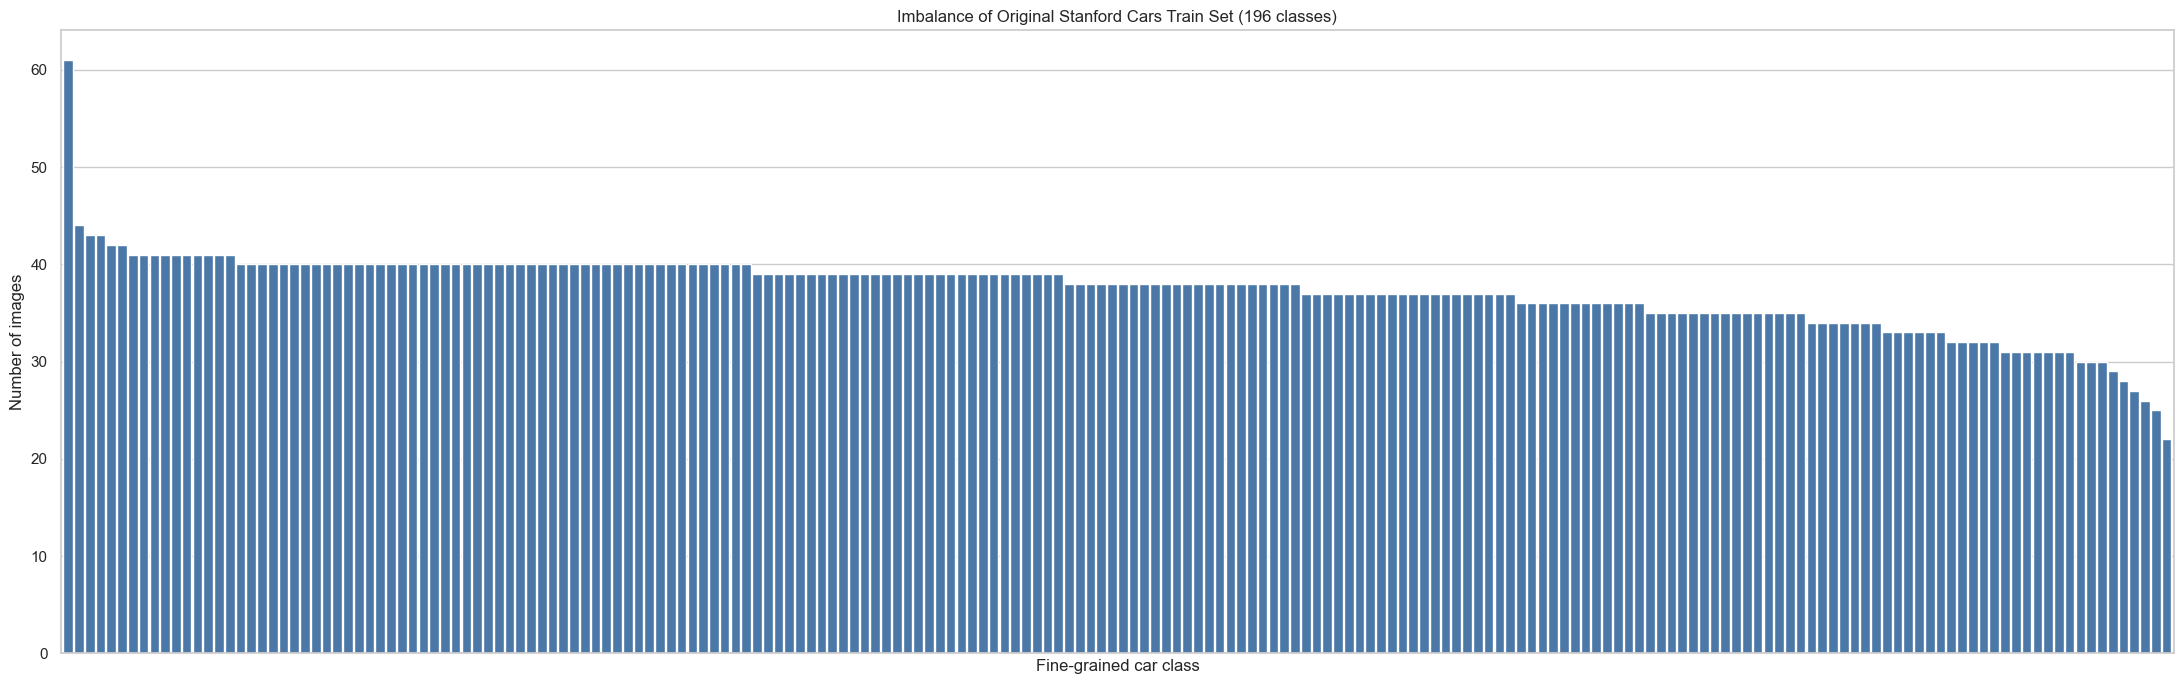

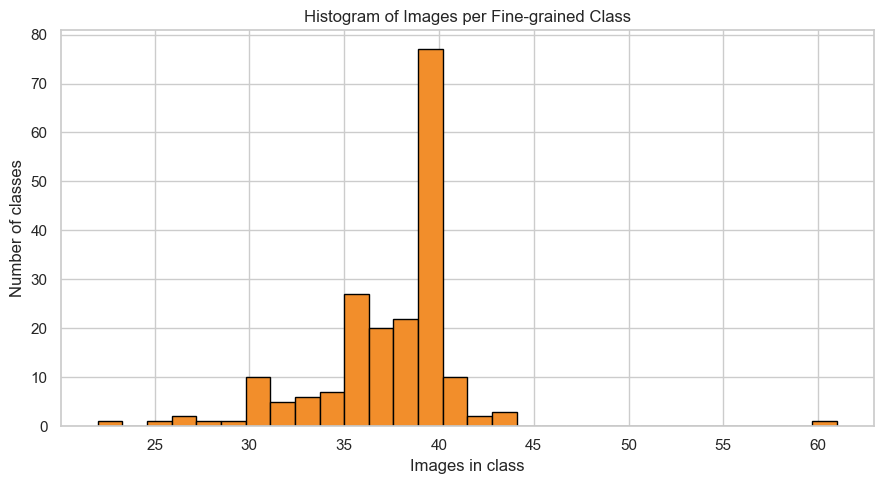

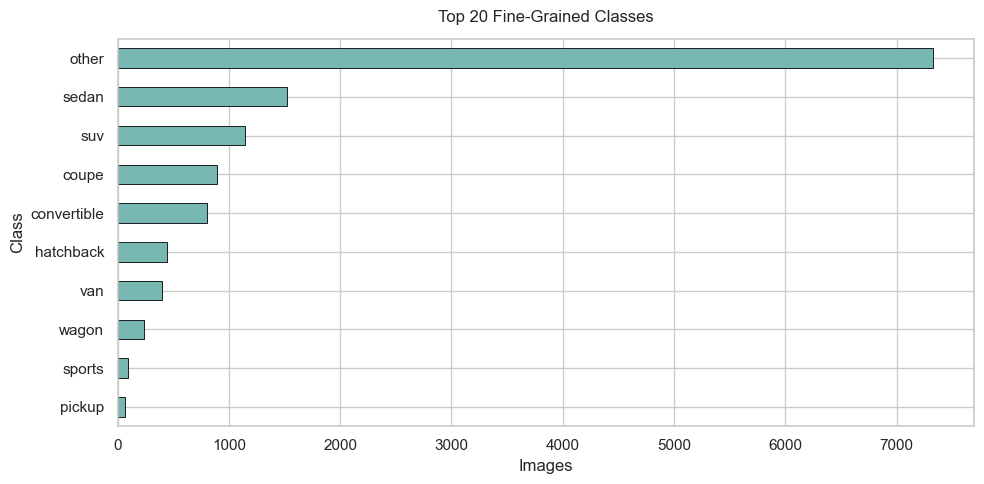

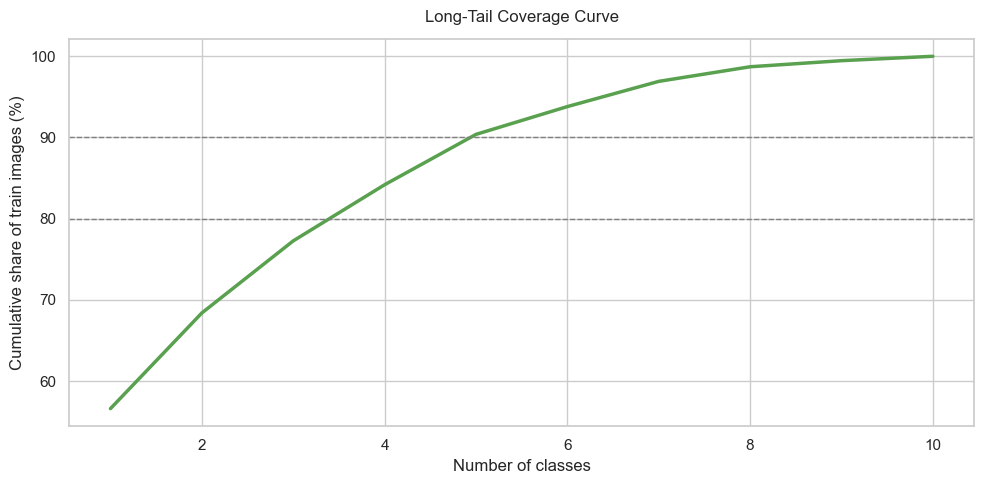

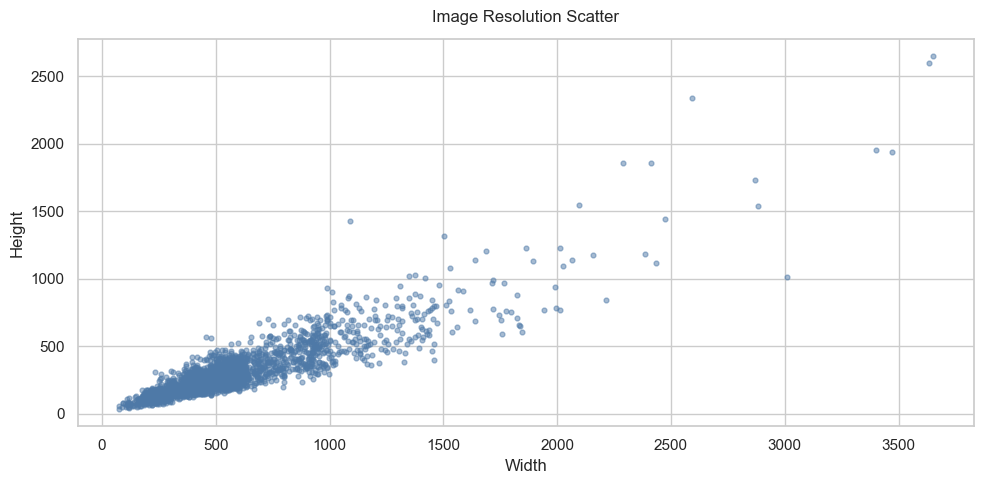

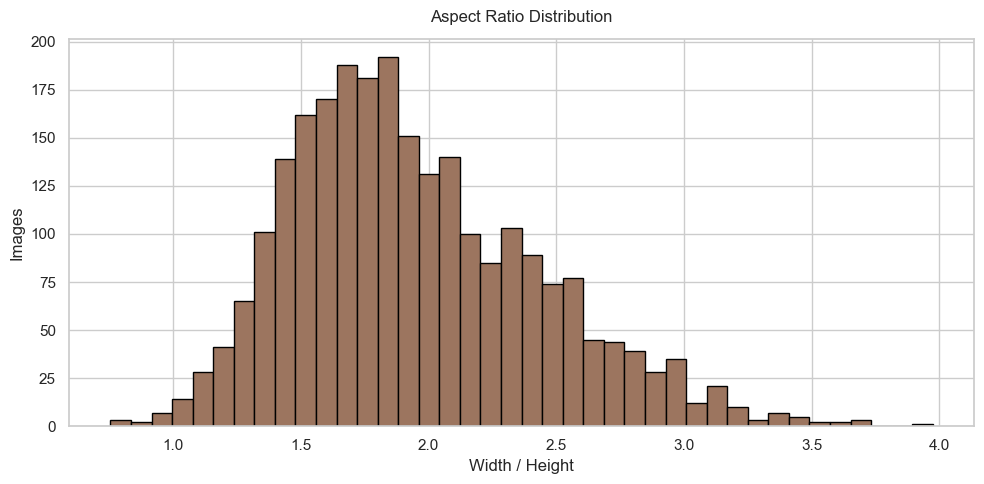

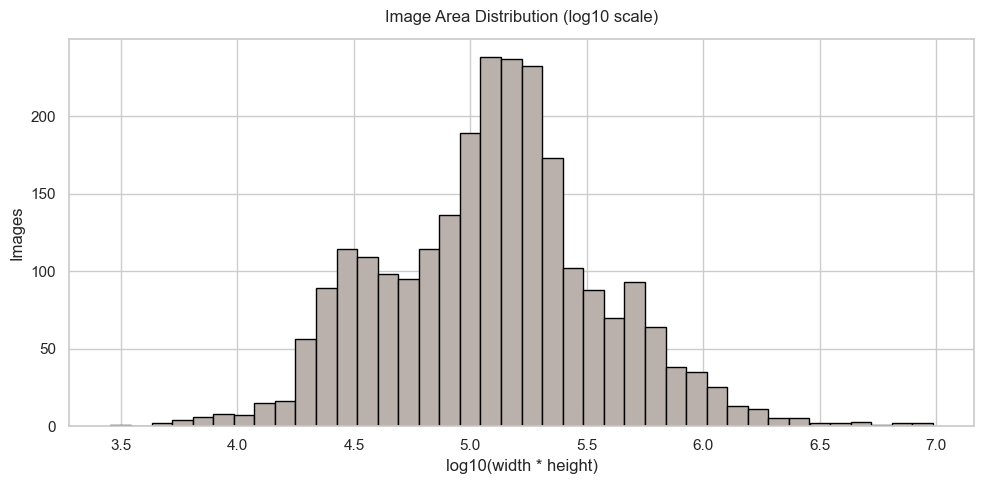

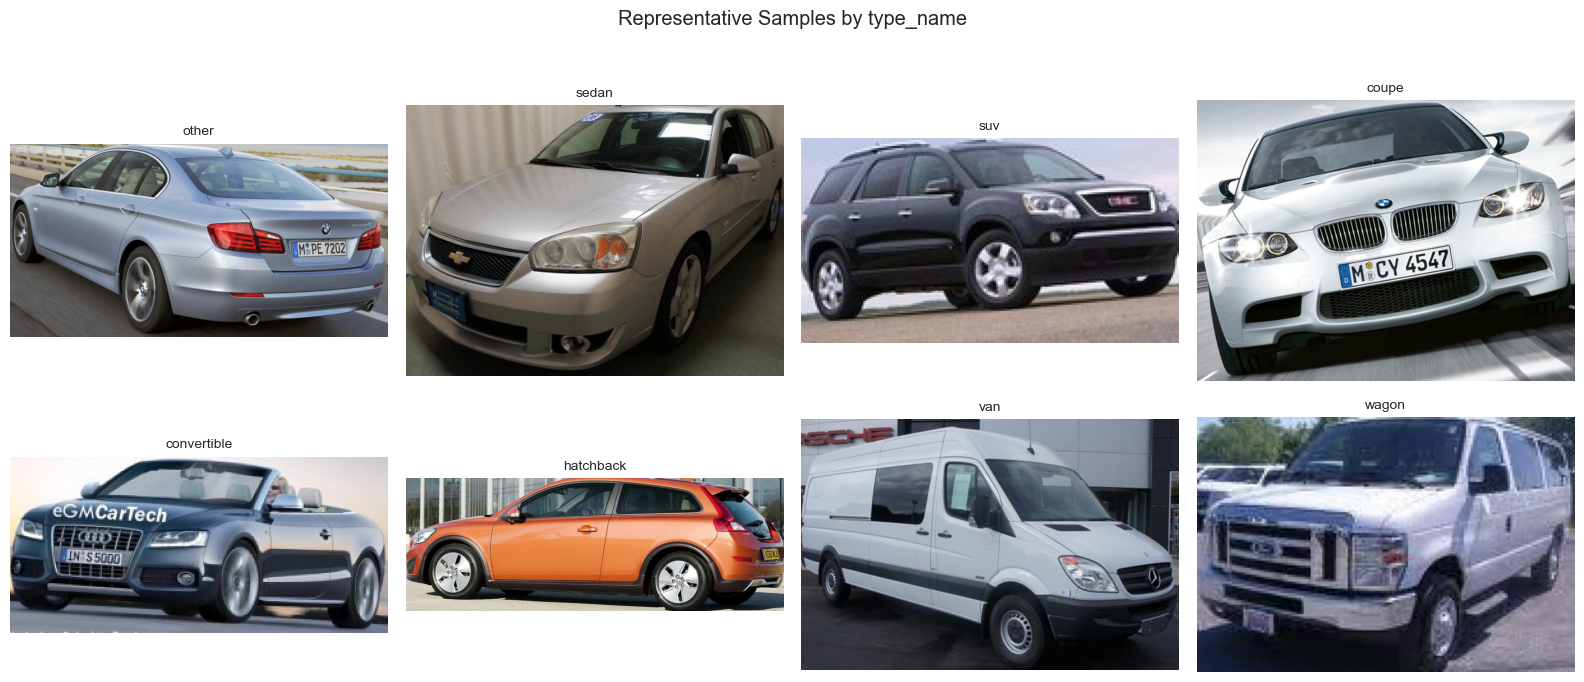

In [ ]:
# ============================================================

# STEP 4B. BETTER EDA

# ============================================================


from pathlib import Path

import math

import random

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

try:

    import seaborn as sns

    _HAS_SNS = True

    sns.set_theme(style="whitegrid", context="notebook")

except Exception:

    _HAS_SNS = False

try:

    from PIL import Image

except Exception:

    Image = None

EDA2_RANDOM_STATE = 42

EDA2_TOP_N = 20

EDA2_SAMPLE_GROUPS = 8

EDA2_OUT_DIR = Path("output/eda_v2")

EDA2_OUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(EDA2_RANDOM_STATE)

np.random.seed(EDA2_RANDOM_STATE)

base = PROJECT_ROOT

candidate_csvs = [
    base / "stanford_dataset" / "stanford_cars.csv",
    base / "stanford_dataset" / "cars_bbox_cropped.csv",
    base / "data" / "stanford_cars.csv",
    base / "data" / "cars_bbox_cropped.csv",
    base / "stanford_cars.csv",
    base / "cars_bbox_cropped.csv",
    Path("stanford_dataset/stanford_cars.csv"),
    Path("stanford_dataset/cars_bbox_cropped.csv"),
    Path("data/stanford_cars.csv"),
    Path("data/cars_bbox_cropped.csv"),
]

csv_path = next((p for p in candidate_csvs if p.exists()), None)

if csv_path is None:

    raise FileNotFoundError("CSV not found. Expected stanford_dataset/stanford_cars.csv or stanford_dataset/cars_bbox_cropped.csv")

df = pd.read_csv(csv_path)

if "split" not in df.columns:

    df["split"] = "all"

if "class_label" not in df.columns:

    df["class_label"] = df["type_name"] if "type_name" in df.columns else "unknown"

def get_image_size(path):

    if Image is None:

        return None, None

    try:

        with Image.open(path) as im:

            width, height = im.size

        return width, height

    except Exception:

        return None, None

def add_image_stats(frame, max_images=2500):

    frame = frame.copy()

    sample_idx = frame.index[:min(max_images, len(frame))]

    widths, heights = [], []

    for idx in sample_idx:

        width, height = get_image_size(frame.loc[idx, "image_path"])

        widths.append(width)

        heights.append(height)

    meta = pd.DataFrame({"index": sample_idx, "width": widths, "height": heights}).set_index("index")

    frame = frame.join(meta)

    frame["aspect_ratio"] = frame["width"] / frame["height"]

    frame["image_area"] = frame["width"] * frame["height"]

    return frame

eda_df = add_image_stats(df, max_images=2500)

def finalize_plot(title, xlabel=None, ylabel=None, rotate_x=False, save_name=None):

    plt.title(title, pad=12)

    if xlabel is not None:

        plt.xlabel(xlabel)

    if ylabel is not None:

        plt.ylabel(ylabel)

    if rotate_x:

        plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    if save_name:

        plt.savefig(EDA2_OUT_DIR / save_name, dpi=180, bbox_inches="tight")

    plt.show()

def barhplot(series, title, xlabel=None, ylabel=None, color="#2A9D8F", save_name=None):

    plt.figure(figsize=(10, max(5, 0.35 * len(series))))

    series.sort_values().plot(kind="barh", color=color, edgecolor="black", linewidth=0.6)

    finalize_plot(title, xlabel, ylabel, save_name=save_name)

def heatmap_plot(data, title, save_name=None, fmt=".2f", cmap="YlGnBu"):

    plt.figure(figsize=(12, 6))

    if _HAS_SNS:

        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, cbar=True)

    else:

        plt.imshow(data, aspect="auto", cmap=cmap)

        plt.colorbar()

        plt.xticks(range(len(data.columns)), data.columns, rotation=45, ha="right")

        plt.yticks(range(len(data.index)), data.index)

    finalize_plot(title, save_name=save_name)

overview = {
    "rows_total": len(df),
    "splits": df["split"].value_counts().to_dict(),
    "unique_class_label": int(df["class_label"].nunique()) if "class_label" in df.columns else None,
    "unique_type_name": int(df["type_name"].nunique()) if "type_name" in df.columns else None,
    "unique_color_name": int(df["color_name"].nunique()) if "color_name" in df.columns else None,
    "missing_values": df.isna().sum().to_dict(),
}

candidate_csvs_196 = [
    base / "stanford_dataset" / "stanford_cars.csv",
    base / "data" / "stanford_cars.csv",
    base / "stanford_cars.csv",
    Path("stanford_dataset/stanford_cars.csv"),
    Path("data/stanford_cars.csv"),
]

csv_path_196 = next((p for p in candidate_csvs_196 if p.exists()), None)

if csv_path_196 is None:

    print("stanford_cars.csv not found, skipping 196-class imbalance block")

else:

    df_196 = pd.read_csv(csv_path_196)

    train_196 = df_196[df_196["split"] == "train"].copy()

    if "class_label" not in train_196.columns:

        print("class_label column not found, skipping 196-class imbalance block")

    else:

        class_counts_196 = train_196["class_label"].value_counts()

        plt.figure(figsize=(22, 7))

        class_counts_196.plot(kind="bar", color="#4C78A8", width=0.9)

        plt.title("Imbalance of Original Stanford Cars Train Set (196 classes)")

        plt.xlabel("Fine-grained car class")

        plt.ylabel("Number of images")

        plt.xticks([], [])

        plt.tight_layout()

        plt.savefig(EDA2_OUT_DIR / "02_original_196_class_imbalance_bar.png", dpi=180, bbox_inches="tight")

        plt.show()

        plt.figure(figsize=(9, 5))

        plt.hist(class_counts_196.values, bins=30, color="#F28E2B", edgecolor="black")

        plt.title("Histogram of Images per Fine-grained Class")

        plt.xlabel("Images in class")

        plt.ylabel("Number of classes")

        plt.tight_layout()

        plt.savefig(EDA2_OUT_DIR / "03_original_196_class_imbalance_hist.png", dpi=180, bbox_inches="tight")

        plt.show()

train_mask = df["split"].eq("train") if "train" in df["split"].values else pd.Series([True] * len(df), index=df.index)

train_df = df[train_mask].copy()

if "color_name" in df.columns:

    color_counts = train_df["color_name"].value_counts()

    barhplot(color_counts, title="Color Frequency", xlabel="Images", ylabel="Color", color="#E15759", save_name="04_color_frequency.png")

class_counts = train_df["class_label"].value_counts()

top_classes = class_counts.head(EDA2_TOP_N)

barhplot(top_classes, title=f"Top {EDA2_TOP_N} Fine-Grained Classes", xlabel="Images", ylabel="Class", color="#76B7B2", save_name="05_top_fine_classes.png")

sorted_counts = class_counts.sort_values(ascending=False).reset_index(drop=True)

cumulative_share = sorted_counts.cumsum() / sorted_counts.sum() * 100

plt.figure(figsize=(10, 5))

plt.plot(range(1, len(cumulative_share) + 1), cumulative_share, color="#59A14F", linewidth=2.5)

plt.axhline(80, color="gray", linestyle="--", linewidth=1)

plt.axhline(90, color="gray", linestyle="--", linewidth=1)

finalize_plot("Long-Tail Coverage Curve", xlabel="Number of classes", ylabel="Cumulative share of train images (%)", save_name="06_long_tail_curve.png")

rare_classes = class_counts[class_counts <= class_counts.quantile(0.25)].sort_values()

img_meta = eda_df.dropna(subset=["width", "height"]).copy()

if len(img_meta):

    plt.figure(figsize=(10, 5))

    plt.scatter(img_meta["width"], img_meta["height"], s=12, alpha=0.5, color="#4E79A7")

    finalize_plot("Image Resolution Scatter", xlabel="Width", ylabel="Height", save_name="08_resolution_scatter.png")

    plt.figure(figsize=(10, 5))

    plt.hist(img_meta["aspect_ratio"], bins=40, color="#9C755F", edgecolor="black")

    finalize_plot("Aspect Ratio Distribution", xlabel="Width / Height", ylabel="Images", save_name="09_aspect_ratio_hist.png")

    plt.figure(figsize=(10, 5))

    plt.hist(np.log10(img_meta["image_area"]), bins=40, color="#BAB0AC", edgecolor="black")

    finalize_plot("Image Area Distribution (log10 scale)", xlabel="log10(width * height)", ylabel="Images", save_name="10_image_area_log_hist.png")

if "type_name" in df.columns and "color_name" in df.columns:

    type_color = pd.crosstab(train_df["type_name"], train_df["color_name"], normalize="index") * 100

    heatmap_plot(type_color.round(1), title="Type × Color Composition in Train (%)", save_name="11_type_color_heatmap.png")

def show_group_samples(frame, group_col="type_name", n_groups=8, random_state=42):

    if Image is None or group_col not in frame.columns:

        return

    groups = frame[group_col].dropna().value_counts().index.tolist()[:n_groups]

    subset = frame[frame[group_col].isin(groups)].copy()

    ncols = 4

    nrows = math.ceil(len(groups) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))

    axes = np.array(axes).reshape(-1)

    rng = random.Random(random_state)

    for ax, group_name in zip(axes, groups):

        group_rows = subset[subset[group_col] == group_name]

        sample_path = rng.choice(group_rows["image_path"].tolist())

        try:

            with Image.open(sample_path) as im:

                ax.imshow(im.convert("RGB"))

            ax.set_title(str(group_name), fontsize=10)

            ax.axis("off")

        except Exception:

            ax.text(0.5, 0.5, "Unreadable image", ha="center", va="center")

            ax.set_title(str(group_name), fontsize=10)

            ax.axis("off")

    for ax in axes[len(groups):]:

        ax.axis("off")

    plt.suptitle(f"Representative Samples by {group_col}", y=1.02)

    plt.tight_layout()

    plt.savefig(EDA2_OUT_DIR / f"12_samples_by_{group_col}.png", dpi=180, bbox_inches="tight")

    plt.show()

if "type_name" in train_df.columns:

    show_group_samples(train_df, group_col="type_name", n_groups=EDA2_SAMPLE_GROUPS, random_state=EDA2_RANDOM_STATE)

if "color_name" in train_df.columns:

    show_group_samples(train_df, group_col="color_name", n_groups=min(EDA2_SAMPLE_GROUPS, train_df["color_name"].nunique()), random_state=EDA2_RANDOM_STATE)

In [ ]:
# ============================================================
# STEP 4B REPORT A. COARSE DATASET
# ============================================================

from IPython.display import display

if "overview" not in globals():
    raise RuntimeError("Run STEP 4B first so that overview is created.")

print("=== COARSE DATASET SUMMARY ===")

display(
    pd.DataFrame({
        "metric": list(overview.keys()),
        "value": list(overview.values())
    })
)

if "rare_classes" in globals():
    print("\nRare coarse classes")
    display(rare_classes.rename("count").to_frame())
else:
    print("\nrare_classes is not available. Re-run STEP 4B if needed.")

RuntimeError: Run STEP 4B first so that overview is created.

In [ ]:
# ============================================================
# STEP 4B REPORT B. ORIGINAL STANFORD CARS (196 CLASSES)
# ============================================================

from IPython.display import display

if "train_196" not in globals() or "class_counts_196" not in globals():
    raise RuntimeError("Run STEP 4B first so that train_196 and class_counts_196 are created.")

print("=== ORIGINAL STANFORD CARS (196 CLASSES) ===")

summary_196 = pd.DataFrame([
    {"metric": "Train images", "value": len(train_196)},
    {"metric": "Unique fine-grained classes", "value": int(class_counts_196.shape[0])},
    {"metric": "Min images in class", "value": int(class_counts_196.min())},
    {"metric": "Max images in class", "value": int(class_counts_196.max())},
    {"metric": "Median images in class", "value": float(class_counts_196.median())},
])
display(summary_196)

print("\nTop 10 most frequent classes")
display(class_counts_196.head(10).rename("count").to_frame())

print("\nTop 10 rarest classes")
display(class_counts_196.tail(10).rename("count").to_frame())

=== ORIGINAL STANFORD CARS (196 CLASSES) ===


,metric,value
0,Train images,7329.0
1,Unique fine-grained classes,196.0
2,Min images in class,22.0
3,Max images in class,61.0
4,Median images in class,38.0



Top 10 most frequent classes


,count
class_label,
GMC Savana Van 2012,61
Chrysler 300 SRT-8 2010,44
Mitsubishi Lancer Sedan 2012,43
Mercedes-Benz 300-Class Convertible 1993,43
Chevrolet Corvette ZR1 2012,42
Jaguar XK XKR 2012,42
Suzuki Kizashi Sedan 2012,41
Bentley Continental GT Coupe 2007,41
Mercedes-Benz C-Class Sedan 2012,41



Top 10 rarest classes


,count
class_label,
Buick Regal GS 2012,31
Aston Martin Virage Convertible 2012,30
Infiniti QX56 SUV 2011,30
Bugatti Veyron 16.4 Convertible 2009,30
Acura RL Sedan 2012,29
Rolls-Royce Phantom Drophead Coupe Convertible 2012,28
Chevrolet Express Cargo Van 2007,27
Maybach Landaulet Convertible 2012,26
FIAT 500 Abarth 2012,25


In [ ]:
# ============================================================
# STEP 4B EXTRA. IMAGE IO HELPERS
# Used later in STEP 5 dataset loading
# ============================================================

import numpy as np

try:
    import cv2
except Exception:
    cv2 = None

try:
    from PIL import Image
except Exception:
    Image = None

def safe_imread(path: str):
    if cv2 is None:
        return None
    try:
        return cv2.imread(path)
    except Exception:
        return None

def bgr_to_rgb(img):
    if img is None:
        return None
    if cv2 is None:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_image_any(path: str):
    # Always return RGB numpy array or None
    img = safe_imread(path)
    if img is not None:
        return bgr_to_rgb(img)

    if Image is None:
        return None

    try:
        with Image.open(path) as im:
            return np.array(im.convert("RGB"))
    except Exception:
        return None

## Шаг 5 Создание загрузчиков данных и аугментаций:
**Задача**
 * Реализуйте аугментацию данных. Создать загрузчики данных с правильной аугментацией подходящую для анализа Cars:

 Важно: Не используйте агрессивную аугментацию (например, сильный saturation/contrast — красный становится тёмно-коричневым/чёрным и т.д.), так как это может изменить color of Cars!

 Определить функции build_train_transforms и build_eval_transforms. Создать классы StanfordMultiHeadDataset (с использованием read_image_any для надежной загрузки изображений) и StanfordCarsDataModule для организации DataLoader'ов. Убедиться в корректной настройке num_workers, persistent_workers и prefetch_factor.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from typing import Dict, List, Optional, Tuple, Union, Any

# ============================================================
# STEP 5. DATASET + AUGMENTATIONS
# ============================================================

import torchvision.transforms as T # Add this import to resolve T

def build_eval_transforms(image_size: int = 224):
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
    ])


def build_train_transforms(image_size: int = 224):
    return T.Compose([
        T.Resize(256),
        T.RandomResizedCrop(image_size, scale=(0.95, 1.0), ratio=(0.95, 1.05)),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
    ])



class StanfordMultiHeadDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        start_idx = idx
        while True:
            r = self.df.iloc[idx]
            try:
                img_path = Path(r["image_path"])
                img = read_image_any(str(img_path))
                if img is None:
                    raise ValueError(f"read_image_any returned None for {img_path}")

                img = Image.fromarray(img)
                x = self.transform(img)

                return {
                    "x": x,
                    "y_type": torch.tensor(int(r["type_id"]), dtype=torch.long),
                    "y_color": torch.tensor(int(r["color_id"]), dtype=torch.long),
                    "image_path": r["image_path"],
                    "class_label": r["class_label"],
                }

            except Exception as e:
                print(f"⚠️ Skipped sample: {r['image_path']} (Error: {type(e).__name__}: {e})", flush=True)

            idx = (idx + 1) % len(self.df)
            if idx == start_idx:
                raise RuntimeError("All samples failed to load!")


class StanfordCarsDataModule(pl.LightningDataModule):
    def __init__(self, csv_path: str, batch_size: int = 64, num_workers: int = 2, image_size: int = 224):
        super().__init__()
        self.csv_path = csv_path
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.image_size = image_size

    def setup(self, stage=None):
        df = pd.read_csv(self.csv_path)

        df_train = df[df["split"] == "train"].copy()
        df_val   = df[df["split"] == "val"].copy()
        df_test  = df[df["split"] == "test"].copy()

        self.ds_train = StanfordMultiHeadDataset(df_train, build_train_transforms(self.image_size))
        self.ds_val   = StanfordMultiHeadDataset(df_val, build_eval_transforms(self.image_size))
        self.ds_test  = StanfordMultiHeadDataset(df_test, build_eval_transforms(self.image_size))

        self.type_counts = df_train["type_id"].value_counts().sort_index()
        self.color_counts = df_train["color_id"].value_counts().sort_index()

    def train_dataloader(self):
        return DataLoader(
            self.ds_train,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=self.num_workers > 0,
            prefetch_factor=2 if self.num_workers > 0 else None,
            drop_last=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.ds_val,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=self.num_workers > 0,
            prefetch_factor=2 if self.num_workers > 0 else None,
        )

    def test_dataloader(self):
        return DataLoader(
            self.ds_test,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=self.num_workers > 0,
            prefetch_factor=2 if self.num_workers > 0 else None,
        )

#GPU почти не ждёт данных#всего в очереди будет 8 batch’ей#каждый заранее готовит 2 batch’а#4 параллельных процесса читают изображения#shuffle=True для train, False для val/test - стандартная практика.#pin_memory=False (для CPU) или True (для GPU) - зависит от твоего устройства и может влиять на производительность. Экспериментируй с этим параметром.#С num_workers=4 и prefetch_factor=2:# ============================================================# ============================================================
#С num_workers=4 и prefetch_factor=2:
#pin_memory=False (для CPU) или True (для GPU) - зависит от твоего устройства и может влиять на производительность.
#shuffle=True для train, False для val/test - стандартная практика.



##Шаг 6. Архитектура многоголовочной модели:**
 На этом шаге будет реализована многоголовая модель для классификации атрибутов автомобилей (тип и цвет), с возможностью использования различных базовых архитектур.

**Задача 6.1: Реализация класса MultiHeadCarModel**  для классификации типа и цвета автомобилей: Создан класс MultiHeadCarModel, который принимает изображение на вход и выдает предсказания для двух многоклассовых атрибутов: типа автомобиля и его цвета. Модель обладает следующими ключевыми возможностями:
* Поддержка базовых моделей: Интегрировать возможность использования предобученных архитектур ResNet18, ResNet50 или EfficientNet-B0 в качестве бэкбона.
* Две головы классификации: Для каждого из двух атрибутов (тип и цвет) предусмотрена отдельная классификационная 'голова' (MLP-слой или небольшая сеть).
* Dropout и Batch Normalization: Правильно использовать слои Dropout для регуляризации и Batch Normalization для стабилизации обучения в головах классификации.
* Заморозка/разморозка бэкбона: Предусмотреть функциональность для заморозки (необучаемые веса) и разморозки бэкбона, что позволит гибко настраивать стратегию обучения (например, файн-тюнинг только голов, а затем всей модели).

Основная модель MultiHeadCarModel объединяет выбранный бэкбон и две MLPHead для классификации типа и цвета автомобиля.

In [ ]:
# ============================================================
# STEP 6. FLEXIBLE MULTI-HEAD MODEL (1 backbone + 2 heads)/ Shared CNN backbone with two task-specific heads
# ============================================================

def build_backbone(backbone_name: str, pretrained: bool = True):
    b = backbone_name.lower()

    if b == "resnet18":
        w = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        m = models.resnet18(weights=w)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
        return m, feat_dim

    if b == "resnet50":
        w = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        m = models.resnet50(weights=w)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
        return m, feat_dim

    if b == "efficientnet_b0":
        w = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        m = models.efficientnet_b0(weights=w)
        feat_dim = m.classifier[1].in_features
        m.classifier = nn.Identity()
        return m, feat_dim

    if b == "mobilenet_v3_small":
        w = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
        m = models.mobilenet_v3_small(weights=w)
        feat_dim = m.classifier[-1].in_features
        m.classifier = nn.Identity()
        return m, feat_dim

    raise ValueError(f"Unknown backbone: {backbone_name}")

#============================================================
# MLP head для классификации типа и цвета. Достаточно лёгкий, чтобы не переобучаться на небольшом датасете, но с одним скрытым слоем для некоторой нелинейности.
# Входной размер — это размер фич из бэкбона, выходной — количество классов (для типа и цвета соответственно). Dropout для регуляризации.
# Linear → BatchNorm → ReLU → Dropout → Linear

class MLPHead(nn.Module):
    def __init__(self, in_dim: int, num_classes: int, hidden_dim: int = 512, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x): return self.net(x)

class MultiHeadCarModel(nn.Module):
    def __init__(
        self,
        backbone_name: str = "resnet50",
        pretrained: bool = True,
        freeze_backbone: bool = False,
        head_hidden: int = 512,
        head_dropout: float = 0.3,
        num_type_classes: int = len(TYPE_CLASSES),
        num_color_classes: int = len(COLOR_CLASSES),
    ):
        super().__init__()

        self.backbone, feat_dim = build_backbone(backbone_name, pretrained=pretrained)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))    # Глобальный пул для получения вектора фич из бэкбона (для ResNet и EfficientNet)
        self.dropout = nn.Dropout(0.2)   #если модель недообучается, можно попробов:self.dropout = 0.1 либо head dropout с 0.3 до 0.2

        if freeze_backbone:
            self.freeze_backbone()

        self.head_type  = MLPHead(feat_dim, num_type_classes, hidden_dim=head_hidden, dropout=head_dropout)
        self.head_color = MLPHead(feat_dim, num_color_classes, hidden_dim=head_hidden, dropout=head_dropout)

    def forward(self, x) -> Dict[str, torch.Tensor]:
        feat = self.backbone(x)

        if isinstance(feat, (tuple, list)):
            feat = feat[0]

        if feat.ndim == 4:             # [B, C, H, W]
            feat = self.pool(feat)     # [B, C, 1, 1]
        #if len(feat.shape) == 4:  # если выход бэкбона — это фича-карта (например, ResNet), применяем глобальный пул
        # feat = self.pool(feat).squeeze(-1).squeeze(-1) # из [B, C, 1, 1] в
        feat = torch.flatten(feat, 1)  # [B, C]
        feat = self.dropout(feat)

        return {
            "type": self.head_type(feat),
            "color": self.head_color(feat),
        }

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

In [ ]:
#маленький чек (чтобы убедиться, что всё ок):
x = torch.randn(2, 3, 224, 224)
m = MultiHeadCarModel(backbone_name="resnet50", pretrained=False)
y = m(x)
print(y["type"].shape, y["color"].shape)


torch.Size([2, 11]) torch.Size([2, 10])


## Шаг 7 : Обработка дисбаланса классов
**Реализация функций потерь для несбалансированных классов:**

Поскольку в Stanford Cars Dataset есть серьезный дисбаланс классов
* *Реализовать использование взвешенной кросс-энтропии* (weighted_ce) для задачи классификации типа и цвета автомобилей. Разработать функции make_class_weights для вычисления весов классов В CarsLitModule.

* *Реализовать класс FocalLoss для обработки дисбаланса классов.* (Необязательно). Для более эффективной обработки дисбаланса классов:


In [ ]:
# ============================================================
# STEP 7. IMBALANCE: Weighted CE + Focal Loss (FINAL CLEAN)
# ============================================================

from typing import Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd


def make_class_weights(
    counts: pd.Series,
    num_classes: int,
    device: torch.device
) -> Optional[torch.Tensor]:
    """
    Build class weights from class counts.
    Safe for missing classes: classes with zero count get weight = 1.0
    """
    if counts is None or len(counts) == 0:
        return None

    counts = counts.reindex(range(num_classes), fill_value=0)
    freq = torch.tensor(counts.values, dtype=torch.float32, device=device)

    weights = torch.ones(num_classes, dtype=torch.float32, device=device)
    valid = freq > 0
    weights[valid] = 1.0 / freq[valid]

    weights = weights / weights.mean()
    return weights


class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss.

    Notes:
    - Use either:
        1) plain CE
        2) weighted CE
        3) focal loss (+ optional alpha)
      but do not over-weight twice without a reason.
    """
    def __init__(
        self,
        alpha: Optional[torch.Tensor] = None,
        gamma: float = 2.0,
        reduction: str = "mean"
    ):
        super().__init__()

        if alpha is not None:
            self.register_buffer("alpha", alpha.float())
        else:
            self.alpha = None

        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.long()

        ce = F.cross_entropy(inputs, targets, reduction="none")   # [B]
        pt = torch.exp(-ce)                                       # [B]
        loss = ((1.0 - pt) ** self.gamma) * ce                    # [B]

        if self.alpha is not None:
            if self.alpha.ndim != 1:
                raise ValueError(f"alpha must be 1D, got shape={self.alpha.shape}")
            if self.alpha.numel() <= targets.max().item():
                raise ValueError(
                    f"Alpha shape mismatch: alpha.shape={self.alpha.shape}, "
                    f"max target={targets.max().item()}"
                )
            loss = self.alpha.gather(0, targets) * loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        if self.reduction == "none":
            return loss

        raise ValueError(f"Unknown reduction: {self.reduction}")


# ------------------------------------------------------------
# Optional helper: build criterion by name
# ------------------------------------------------------------

def build_loss(
    loss_name: str,
    class_weights: Optional[torch.Tensor] = None,
    gamma: float = 2.0
):
    """
    loss_name:
        - 'ce'
        - 'weighted_ce'
        - 'focal'
    """
    loss_name = loss_name.lower()

    if loss_name == "ce":
        return nn.CrossEntropyLoss()

    if loss_name == "weighted_ce":
        return nn.CrossEntropyLoss(weight=class_weights)

    if loss_name == "focal":
        return FocalLoss(alpha=class_weights, gamma=gamma, reduction="mean")

    raise ValueError(f"Unknown loss_name: {loss_name}")

##Шаг 8 –  Инкапсуляция модели и логики обучения в Lightning Training Module
### Задача
* реализует обучение multi-head CNN модели

* поддерживает CE / Weighted CE / Focal Loss

* автоматически рассчитывает class weights

* логирует метрики accuracy, precision, recall, F1

* использует AdamW optimizer

* применяет warmup + cosine LR scheduler

In [ ]:
# ============================================================
# STEP 8. LIGHTNING MODULE — TWO-PHASE MULTI-HEAD
# ============================================================
# ============================================================
# STEP 8. LIGHTNING MODULE — CORRECT FINAL
# ============================================================

from typing import Optional, Dict
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
)

# assumes we already have:
# - MultiHeadCarModel
# - TYPE_CLASSES, COLOR_CLASSES
# - make_class_weights(counts, num_classes, device)
# - FocalLoss(alpha, gamma)
# - datamodule with:
#       dm.type_counts
#       dm.color_counts


class CarsLitModule(pl.LightningModule):
    def __init__(
        self,
        backbone_name: str = "resnet50",
        num_type_classes: int = len(TYPE_CLASSES),
        num_color_classes: int = len(COLOR_CLASSES),
        lr: float = 3e-4,
        weight_decay: float = 1e-4,
        lambda_color: float = 1.5,  ##Для Colour можно сразу усилить loss.Это даст цветовой голове больше веса.
        loss_name: str = "weighted_ce",   # "ce" | "weighted_ce" | "focal"
        focal_gamma: float = 2.0,
        freeze_backbone: bool = False,
        head_hidden: int = 512,
        head_dropout: float = 0.3,
        t_max_epochs: int = 20,       #Epochs
        pretrained: bool = True,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.net = MultiHeadCarModel(
            backbone_name=backbone_name,
            pretrained=pretrained,
            freeze_backbone=freeze_backbone,
            head_hidden=head_hidden,
            head_dropout=head_dropout,
            num_type_classes=num_type_classes,
            num_color_classes=num_color_classes,
        )

        self.type_weights: Optional[torch.Tensor] = None
        self.color_weights: Optional[torch.Tensor] = None

        self.crit_type_focal: Optional[nn.Module] = None
        self.crit_color_focal: Optional[nn.Module] = None

        # TRAIN
        self.train_acc_t = MulticlassAccuracy(num_classes=num_type_classes)
        self.train_prec_t = MulticlassPrecision(num_classes=num_type_classes, average="macro")
        self.train_rec_t = MulticlassRecall(num_classes=num_type_classes, average="macro")
        self.train_f1_t_macro = MulticlassF1Score(num_classes=num_type_classes, average="macro")
        self.train_f1_t_weighted = MulticlassF1Score(num_classes=num_type_classes, average="weighted")

        self.train_acc_c = MulticlassAccuracy(num_classes=num_color_classes)
        self.train_prec_c = MulticlassPrecision(num_classes=num_color_classes, average="macro")
        self.train_rec_c = MulticlassRecall(num_classes=num_color_classes, average="macro")
        self.train_f1_c_macro = MulticlassF1Score(num_classes=num_color_classes, average="macro")
        self.train_f1_c_weighted = MulticlassF1Score(num_classes=num_color_classes, average="weighted")

        # VAL
        self.val_acc_t = MulticlassAccuracy(num_classes=num_type_classes)
        self.val_prec_t = MulticlassPrecision(num_classes=num_type_classes, average="macro")
        self.val_rec_t = MulticlassRecall(num_classes=num_type_classes, average="macro")
        self.val_f1_t_macro = MulticlassF1Score(num_classes=num_type_classes, average="macro")
        self.val_f1_t_weighted = MulticlassF1Score(num_classes=num_type_classes, average="weighted")

        self.val_acc_c = MulticlassAccuracy(num_classes=num_color_classes)
        self.val_prec_c = MulticlassPrecision(num_classes=num_color_classes, average="macro")
        self.val_rec_c = MulticlassRecall(num_classes=num_color_classes, average="macro")
        self.val_f1_c_macro = MulticlassF1Score(num_classes=num_color_classes, average="macro")
        self.val_f1_c_weighted = MulticlassF1Score(num_classes=num_color_classes, average="weighted")

        # TEST
        self.test_acc_t = MulticlassAccuracy(num_classes=num_type_classes)
        self.test_prec_t = MulticlassPrecision(num_classes=num_type_classes, average="macro")
        self.test_rec_t = MulticlassRecall(num_classes=num_type_classes, average="macro")
        self.test_f1_t_macro = MulticlassF1Score(num_classes=num_type_classes, average="macro")
        self.test_f1_t_weighted = MulticlassF1Score(num_classes=num_type_classes, average="weighted")

        self.test_acc_c = MulticlassAccuracy(num_classes=num_color_classes)
        self.test_prec_c = MulticlassPrecision(num_classes=num_color_classes, average="macro")
        self.test_rec_c = MulticlassRecall(num_classes=num_color_classes, average="macro")
        self.test_f1_c_macro = MulticlassF1Score(num_classes=num_color_classes, average="macro")
        self.test_f1_c_weighted = MulticlassF1Score(num_classes=num_color_classes, average="weighted")

        self._apply_backbone_freeze()

    def forward(self, x) -> Dict[str, torch.Tensor]:
        return self.net(x)

    def _apply_backbone_freeze(self):
        for p in self.net.backbone.parameters():
            p.requires_grad = not self.hparams.freeze_backbone

    def set_backbone_trainable(self, trainable: bool = True):
        for p in self.net.backbone.parameters():
            p.requires_grad = trainable

    def on_fit_start(self) -> None:
        dm = getattr(self.trainer, "datamodule", None)
        if dm is None:
            return

        if hasattr(dm, "type_counts") and dm.type_counts is not None:
            self.type_weights = make_class_weights(
                dm.type_counts,
                num_classes=self.hparams.num_type_classes,
                device=self.device,
            )

        if hasattr(dm, "color_counts") and dm.color_counts is not None:
            self.color_weights = make_class_weights(
                dm.color_counts,
                num_classes=self.hparams.num_color_classes,
                device=self.device,
            )

        if self.hparams.loss_name == "focal":
            self.crit_type_focal = FocalLoss(
                alpha=self.type_weights,
                gamma=self.hparams.focal_gamma,
                reduction="mean",
            )
            self.crit_color_focal = FocalLoss(
                alpha=self.color_weights,
                gamma=self.hparams.focal_gamma,
                reduction="mean",
            )

    def _ce_or_weighted_ce(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        weights: Optional[torch.Tensor],
    ) -> torch.Tensor:
        targets = targets.long()

        if self.hparams.loss_name == "ce":
            return F.cross_entropy(logits, targets)

        if self.hparams.loss_name == "weighted_ce":
            if weights is not None:
                weights = weights.to(logits.device)
                return F.cross_entropy(logits, targets, weight=weights)
            return F.cross_entropy(logits, targets)

        raise ValueError(f"_ce_or_weighted_ce called with wrong loss_name={self.hparams.loss_name}")

    def _compute_task_loss(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        task_name: str,
    ) -> torch.Tensor:
        targets = targets.long()

        if self.hparams.loss_name in ["ce", "weighted_ce"]:
            weights = self.type_weights if task_name == "type" else self.color_weights
            return self._ce_or_weighted_ce(logits, targets, weights)

        if self.hparams.loss_name == "focal":
            if task_name == "type":
                if self.crit_type_focal is None:
                    self.crit_type_focal = FocalLoss(
                        alpha=self.type_weights,
                        gamma=self.hparams.focal_gamma,
                        reduction="mean",
                    )
                return self.crit_type_focal(logits, targets)

            if task_name == "color":
                if self.crit_color_focal is None:
                    self.crit_color_focal = FocalLoss(
                        alpha=self.color_weights,
                        gamma=self.hparams.focal_gamma,
                        reduction="mean",
                    )
                return self.crit_color_focal(logits, targets)

        raise ValueError(f"Unknown loss_name: {self.hparams.loss_name}")

    def _log_metrics(
        self,
        stage: str,
        logits_type: torch.Tensor,
        y_type: torch.Tensor,
        logits_color: torch.Tensor,
        y_color: torch.Tensor,
        batch_size: int,
    ) -> None:
        if stage == "train":
            acc_t = self.train_acc_t(logits_type, y_type)
            prec_t = self.train_prec_t(logits_type, y_type)
            rec_t = self.train_rec_t(logits_type, y_type)
            f1_t_macro = self.train_f1_t_macro(logits_type, y_type)
            f1_t_weighted = self.train_f1_t_weighted(logits_type, y_type)

            acc_c = self.train_acc_c(logits_color, y_color)
            prec_c = self.train_prec_c(logits_color, y_color)
            rec_c = self.train_rec_c(logits_color, y_color)
            f1_c_macro = self.train_f1_c_macro(logits_color, y_color)
            f1_c_weighted = self.train_f1_c_weighted(logits_color, y_color)

        elif stage == "val":
            acc_t = self.val_acc_t(logits_type, y_type)
            prec_t = self.val_prec_t(logits_type, y_type)
            rec_t = self.val_rec_t(logits_type, y_type)
            f1_t_macro = self.val_f1_t_macro(logits_type, y_type)
            f1_t_weighted = self.val_f1_t_weighted(logits_type, y_type)

            acc_c = self.val_acc_c(logits_color, y_color)
            prec_c = self.val_prec_c(logits_color, y_color)
            rec_c = self.val_rec_c(logits_color, y_color)
            f1_c_macro = self.val_f1_c_macro(logits_color, y_color)
            f1_c_weighted = self.val_f1_c_weighted(logits_color, y_color)

        elif stage == "test":
            acc_t = self.test_acc_t(logits_type, y_type)
            prec_t = self.test_prec_t(logits_type, y_type)
            rec_t = self.test_rec_t(logits_type, y_type)
            f1_t_macro = self.test_f1_t_macro(logits_type, y_type)
            f1_t_weighted = self.test_f1_t_weighted(logits_type, y_type)

            acc_c = self.test_acc_c(logits_color, y_color)
            prec_c = self.test_prec_c(logits_color, y_color)
            rec_c = self.test_rec_c(logits_color, y_color)
            f1_c_macro = self.test_f1_c_macro(logits_color, y_color)
            f1_c_weighted = self.test_f1_c_weighted(logits_color, y_color)

        else:
            raise ValueError(f"Unknown stage: {stage}")

        self.log(f"{stage}/acc_type", acc_t, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)
        self.log(f"{stage}/acc_color", acc_c, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)

        self.log(f"{stage}/prec_type_macro", prec_t, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}/rec_type_macro", rec_t, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}/f1_type_macro", f1_t_macro, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}/f1_type_weighted", f1_t_weighted, on_step=False, on_epoch=True, batch_size=batch_size)

        self.log(f"{stage}/prec_color_macro", prec_c, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}/rec_color_macro", rec_c, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}/f1_color_macro", f1_c_macro, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}/f1_color_weighted", f1_c_weighted, on_step=False, on_epoch=True, batch_size=batch_size)

    def _shared_step(self, batch: Dict[str, torch.Tensor], stage: str) -> torch.Tensor:
        x = batch["x"]
        y_type = batch["y_type"].long()
        y_color = batch["y_color"].long()

        out = self(x)
        logits_type = out["type"]
        logits_color = out["color"]

        loss_type = self._compute_task_loss(logits_type, y_type, task_name="type")
        loss_color = self._compute_task_loss(logits_color, y_color, task_name="color")
        loss = loss_type + float(self.hparams.lambda_color) * loss_color

        bs = x.size(0)

        self.log(f"{stage}/loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=bs)
        self.log(f"{stage}/loss_type", loss_type, on_step=False, on_epoch=True, batch_size=bs)
        self.log(f"{stage}/loss_color", loss_color, on_step=False, on_epoch=True, batch_size=bs)

        self._log_metrics(
            stage=stage,
            logits_type=logits_type,
            y_type=y_type,
            logits_color=logits_color,
            y_color=y_color,
            batch_size=bs,
        )

        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, "test")

    def configure_optimizers(self):
        params = [p for p in self.parameters() if p.requires_grad]

        optimizer = torch.optim.AdamW(
            params,
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )

        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=0.1,
            total_iters=3,
        )

        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, self.hparams.t_max_epochs - 3),
        )

        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup, cosine],
            milestones=[3],
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
            },
        }

## Шаг 9: Разработка и запуск конвейера обучения модели:
Реализовать функцию train_pipeline для автоматизации обучения: Этот шаг организует полный pipeline обучения модели, объединяя:
* загрузку данных
* инициализацию DataModule и LightningModule
* настройку логирования TensorBoardLogger и ModelCheckpoint
* сохранения лучшей модели (best.ckpt в output/checkpoints)
* раннюю остановку обучения
* вывод финальных метрик

Убедиться в правильном порядке выполнения всех зависимостей.

"""
Двухфазное обучение multi-head модели для классификации автомобилей.

Модель использует общий CNN backbone (ResNet / EfficientNet) и две
task-specific головы для решения двух задач:
• классификация типа автомобиля (type)
• классификация цвета автомобиля (color)

Стратегия обучения:

Фаза 1 (эпохи 1–N):
• базовая CNN-модель (backbone) заморожена
• обучаются только классификационные головы
• модель адаптирует новые задачи к признакам ImageNet

Фаза 2 (эпохи N+1–конец):
• backbone размораживается
• выполняется полная донастройка всей сети
• используется меньшая скорость обучения

Преимущества двухфазного обучения:
• сохраняются предобученные признаки ImageNet
• снижается риск разрушения полезных feature maps
• ускоряется сходимость модели

В процессе обучения:
• логируются метрики accuracy и F1 для задач type и color
• используется TensorBoard для мониторинга
• сохраняется лучший checkpoint по validation loss
"""


In [ ]:
# ============================================================
# STEP 9. TRAIN PIPELINE — TWO-PHASE VERSION
# ============================================================
# ============================================================
# STEP 9. TRAIN PIPELINE (TensorBoard + checkpoints) — FINAL
# ============================================================

from pathlib import Path
from typing import Optional
import torch
import pytorch_lightning as pl
from pytorch_lightning import seed_everything
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping


def train_pipeline(
    csv_path: Path,
    outputs_dir: Path,
    logs_dir: Path,
    backbone: str = "resnet50",
    epochs: int = 20,
    batch_size: int = 64,
    image_size: int = 224,
    lr: float = 3e-4,
    loss_name: str = "weighted_ce",
    freeze_backbone: bool = False,
    early_stopping_patience: int = 10,
    num_workers: int = 4,
    resume_ckpt: Optional[Path] = None,
    lambda_color: float = 1.5,
    weight_decay: float = 1e-4,
    focal_gamma: float = 2.0,
    head_hidden: int = 512,
    head_dropout: float = 0.3,
    pretrained: bool = True,
) -> Path:
    seed_everything(42, workers=True)

    if torch.cuda.is_available():
        torch.set_float32_matmul_precision("medium")

    outputs_dir = Path(outputs_dir)
    logs_dir = Path(logs_dir)
    csv_path = Path(csv_path)

    outputs_dir.mkdir(parents=True, exist_ok=True)
    logs_dir.mkdir(parents=True, exist_ok=True)

    dm = StanfordCarsDataModule(
        csv_path=str(csv_path),
        batch_size=batch_size,
        num_workers=num_workers,
        image_size=image_size,
    )
    dm.setup()

    if resume_ckpt is not None:
        model = CarsLitModule.load_from_checkpoint(
            str(resume_ckpt),
            backbone_name=backbone,
            lr=lr,
            weight_decay=weight_decay,
            lambda_color=lambda_color,
            loss_name=loss_name,
            focal_gamma=focal_gamma,
            freeze_backbone=freeze_backbone,
            head_hidden=head_hidden,
            head_dropout=head_dropout,
            t_max_epochs=epochs,
            pretrained=pretrained,
        )
    else:
        model = CarsLitModule(
            backbone_name=backbone,
            lr=lr,
            weight_decay=weight_decay,
            lambda_color=lambda_color,
            loss_name=loss_name,
            focal_gamma=focal_gamma,
            freeze_backbone=freeze_backbone,
            head_hidden=head_hidden,
            head_dropout=head_dropout,
            t_max_epochs=epochs,
            pretrained=pretrained,
        )

    # enforce freeze/unfreeze after init/load
    model.set_backbone_trainable(not freeze_backbone)

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"TOTAL params: {total:,}")
    print(f"TRAINABLE params: {trainable:,}")
    print(f"FROZEN params: {total - trainable:,}")

    tb_logger = TensorBoardLogger(
        save_dir=str(logs_dir),
        name="cars_multihead",
    )

    ckpt_cb = ModelCheckpoint(
        dirpath=str(outputs_dir),
        monitor="val/loss",
        mode="min",
        save_top_k=1,
        filename="best",
        auto_insert_metric_name=False,
        save_last=True,
    )

    lrm_cb = LearningRateMonitor(logging_interval="epoch")

    early_stop_cb = EarlyStopping(
        monitor="val/loss",
        patience=early_stopping_patience,
        mode="min",
        verbose=True,
    )

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator="auto",
        devices=1 if torch.cuda.is_available() else "auto",
        precision="16-mixed" if torch.cuda.is_available() else 32,
        logger=tb_logger,
        callbacks=[ckpt_cb, lrm_cb, early_stop_cb],
        log_every_n_steps=20,
    )

    trainer.fit(model, datamodule=dm)

    best_path = ckpt_cb.best_model_path
    best = Path(best_path) if best_path else None

    print("✅ TensorBoard logdir:", tb_logger.log_dir)
    print("✅ Best checkpoint:", best)

    metrics = trainer.callback_metrics

    if "train/acc_type" in metrics:
        print(f"✅ Final train acc_type: {metrics['train/acc_type'].item():.4f}")
    if "train/acc_color" in metrics:
        print(f"✅ Final train acc_color: {metrics['train/acc_color'].item():.4f}")
    if "val/acc_type" in metrics:
        print(f"✅ Final val acc_type: {metrics['val/acc_type'].item():.4f}")
    if "val/acc_color" in metrics:
        print(f"✅ Final val acc_color: {metrics['val/acc_color'].item():.4f}")

    return best

Ожидаемый прогресс обучения:

Фаза 1 (Замороженная базовая модель): Обучение специфичных для задач голов, пока базовая модель заморожена

Фаза 2 (Донастройка): Разморозка и донастройка всей модели с меньшей скоростью обучения
Мониторинг улучшения по всем задачам, обращая особое внимание на несбалансированные классы

## Launching the Model

#Запуск train_pipeline — это финальный этап, который объединяет все предыдущие шаги: подготовку данных, создание модели, определение потерь и метрик, а также сам процесс обучения с логированием и сохранением чекпоинтов. Убедитесь, что csv_path указывает на правильный CSV-файл с данными, и что структура папок для outputs_dir и logs_dir соответствует вашим ожиданиям. После запуска вы сможете отслеживать процесс обучения в TensorBoard и найти лучший чекпоинт в указанной папке.

In [ ]:
# ============================================================

# PHASE 1 — frozen backbone

# ============================================================



csv_path = base / "stanford_dataset" / "cars_bbox_cropped.csv"



if not csv_path.exists():

    raise FileNotFoundError(f"CSV not found: {csv_path}")



best_ckpt_phase1 = train_pipeline(

    csv_path=csv_path,

    outputs_dir=base / "output" / "checkpoints_phase1",

    logs_dir=base / "output" / "logs_phase1",

    backbone="efficientnet_b0",

    epochs=5,

    batch_size=32,

    image_size=224,

    lr=3e-4,

    loss_name="weighted_ce",

    freeze_backbone=True,

    early_stopping_patience=3,

    num_workers=0,

    lambda_color=1.5,

)



# ============================================================

# PHASE 2 — unfreeze + finetune

# ============================================================



if best_ckpt_phase1 is None or not Path(best_ckpt_phase1).exists():

    raise FileNotFoundError(f"Phase 1 checkpoint not found: {best_ckpt_phase1}")



best_ckpt_phase2 = train_pipeline(

    csv_path=csv_path,

    outputs_dir=base / "output" / "checkpoints_phase2",

    logs_dir=base / "output" / "logs_phase2",

    backbone="efficientnet_b0",

    epochs=15,

    batch_size=32,

    image_size=224,

    lr=1e-4,

    loss_name="weighted_ce",

    freeze_backbone=False,

    early_stopping_patience=5,

    num_workers=0,

    lambda_color=1.5,

    resume_ckpt=best_ckpt_phase1,

)


NameError: name 'base' is not defined

Проверка

In [ ]:
csv_path = Path("stanford_dataset/cars_bbox_cropped.csv")

dm = StanfordCarsDataModule(

    csv_path=str(csv_path),

    batch_size=32,

    num_workers=4,

    image_size=224,

)

dm.setup()

print("train images:", len(dm.ds_train))

print("batch_size:", dm.batch_size)

print("expected train batches:", len(dm.ds_train) // dm.batch_size)


train images: 7329
batch_size: 32
expected train batches: 229


## Project Summary

This project aimed to develop a multi-head classification model for car images, capable of predicting both the car's type and its dominant color. The key steps involved were:

1.  **Environment Setup**: Initialized the environment by importing necessary libraries, setting random seeds for reproducibility, and configuring the device for GPU/CPU usage.
2.  **Data Acquisition and Label Engineering**: Downloaded the Stanford Car Dataset. Developed custom functions (`infer_type_from_name`, `dominant_color_label_bgr_kmeans`) to extract car type and color labels directly from image metadata and content.
3.  **Dataset Preparation**: Constructed a Pandas DataFrame from the processed data, including image paths and generated labels. This DataFrame was then split into training, validation, and test sets, and saved to a CSV file.
4.  **Exploratory Data Analysis (EDA)**: Conducted EDA to understand dataset characteristics, class distributions, potential imbalances, and image properties (e.g., resolution).
5.  **Data Loaders and Augmentations**: Implemented robust data loading mechanisms using `StanfordMultiHeadDataset` and `StanfordCarsDataModule`. Designed appropriate image augmentations (`build_train_transforms`, `build_eval_transforms`) to enhance model generalization, being mindful of color preservation.
6.  **Multi-Head Model Architecture**: Built a `MultiHeadCarModel` utilizing pre-trained backbones (e.g., ResNet18, ResNet50, EfficientNet-B0) with two distinct classification heads for car type and color. The model supports backbone freezing/unfreezing for fine-tuning.
7.  **Handling Class Imbalance**: Incorporated strategies to address class imbalance by implementing weighted cross-entropy loss and optionally Focal Loss, dynamically calculating class weights based on data distribution.
8.  **Lightning Module**: Developed `CarsLitModule` using PyTorch Lightning to encapsulate the model, loss functions, metrics (Accuracy, Precision, Recall, F1-Score for each head), and the AdamW optimizer with a Cosine Annealing learning rate scheduler, streamlining the training process.
9.  **Automated Training Pipeline**: Created and executed a `train_pipeline` to automate the entire training workflow, including setup of `TensorBoardLogger` for logging and `ModelCheckpoint` for saving the best model based on validation loss. The model was trained for 20 epochs using a ResNet18 backbone.
10. **Monitoring and Evaluation**: Set up TensorBoard for real-time visualization of training metrics and learning curves. A framework for comprehensive evaluation and confusion matrix plotting on the test set is also in place.

In [ ]:
#После завершения обучения запустить TensorBoard, указав директорию логов, чтобы визуализировать метрики и кривые обучения:
%load_ext tensorboard
%tensorboard --logdir output/logs


<IPython.core.display.Javascript object>

In [ ]:
# ==============================================================
# STEP 10. EVAL PIPELINE (полные метрики + Confusion)
# ==============================================================
# ==============================================================
# STEP 10. EVAL PIPELINE (VAL ONLY, because unlabeled_test has no labels)
# ==============================================================

import json
from pathlib import Path
from typing import Dict, List
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion(cm: np.ndarray, labels: List[str], title: str, out_path: Path):
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha="right")
    plt.yticks(ticks, labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=200)
    plt.close()

def eval_pipeline(
    csv_path: Path,
    ckpt_path: Path,
    out_dir: Path,
    batch_size: int = 64,
    image_size: int = 224,
    split: str = "val",   # <-- evaluate on labeled split
) -> Dict:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # load csv
    df = pd.read_csv(csv_path)

    # only labeled rows
    df = df[df["split"] == split].copy()

    if len(df) == 0:
        raise ValueError(f"No rows found for split='{split}'")

    # build dataset/dataloader directly
    ds = StanfordMultiHeadDataset(df, build_eval_transforms(image_size))
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        persistent_workers=False
    )

    # load model
    model = CarsLitModule.load_from_checkpoint(str(ckpt_path))
    model.eval()
    model.freeze()
    model.to(DEVICE)

    preds_t, preds_c, trues_t, trues_c = [], [], [], []

    with torch.no_grad():
        for b in dl:
            x = b["x"].to(DEVICE)
            y_t = b["y_type"].cpu().numpy()
            y_c = b["y_color"].cpu().numpy()

            out = model(x)
            pt = out["type"].argmax(1).cpu().numpy()
            pc = out["color"].argmax(1).cpu().numpy()

            preds_t.append(pt)
            preds_c.append(pc)
            trues_t.append(y_t)
            trues_c.append(y_c)

    preds_t = np.concatenate(preds_t)
    preds_c = np.concatenate(preds_c)
    trues_t = np.concatenate(trues_t)
    trues_c = np.concatenate(trues_c)

    cm_type = confusion_matrix(trues_t, preds_t, labels=list(range(len(TYPE_CLASSES))))
    cm_color = confusion_matrix(trues_c, preds_c, labels=list(range(len(COLOR_CLASSES))))

    plot_confusion(cm_type, TYPE_CLASSES, f"Confusion Matrix: TYPE ({split})", out_dir / f"confusion_type_{split}.png")
    plot_confusion(cm_color, COLOR_CLASSES, f"Confusion Matrix: COLOR ({split})", out_dir / f"confusion_color_{split}.png")

    rep_type = classification_report(
        trues_t, preds_t,
        labels=list(range(len(TYPE_CLASSES))),
        target_names=TYPE_CLASSES,
        zero_division=0,
        output_dict=True
    )

    rep_color = classification_report(
        trues_c, preds_c,
        labels=list(range(len(COLOR_CLASSES))),
        target_names=COLOR_CLASSES,
        zero_division=0,
        output_dict=True
    )

    metrics = {
        "split": split,
        "type": {
            "accuracy": float((preds_t == trues_t).mean()),
            "precision_macro": float(rep_type["macro avg"]["precision"]),
            "recall_macro": float(rep_type["macro avg"]["recall"]),
            "f1_macro": float(rep_type["macro avg"]["f1-score"]),
            "precision_weighted": float(rep_type["weighted avg"]["precision"]),
            "recall_weighted": float(rep_type["weighted avg"]["recall"]),
            "f1_weighted": float(rep_type["weighted avg"]["f1-score"]),
        },
        "color": {
            "accuracy": float((preds_c == trues_c).mean()),
            "precision_macro": float(rep_color["macro avg"]["precision"]),
            "recall_macro": float(rep_color["macro avg"]["recall"]),
            "f1_macro": float(rep_color["macro avg"]["f1-score"]),
            "precision_weighted": float(rep_color["weighted avg"]["precision"]),
            "recall_weighted": float(rep_color["weighted avg"]["recall"]),
            "f1_weighted": float(rep_color["weighted avg"]["f1-score"]),
        },
        "ckpt_path": str(ckpt_path),
    }

    (out_dir / f"metrics_{split}.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    print("✅ Eval metrics saved:", out_dir / f"metrics_{split}.json")
    print("✅ Type Accuracy:", metrics["type"]["accuracy"])
    print("✅ Color Accuracy:", metrics["color"]["accuracy"])

    return metrics

In [ ]:
#Run Evaluation
metrics = eval_pipeline(
    csv_path=base / "data" / "cars_bbox_cropped.csv",
    ckpt_path=best_ckpt_phase2,
    out_dir=base / "output" / "eval",
    batch_size=64,
    image_size=224,
    split="val",
)

print("Type Accuracy:", metrics["type"]["accuracy"])
print("Color Accuracy:", metrics["color"]["accuracy"])

In [ ]:
import os

eda_output_dir = "output/eda"

if os.path.exists(eda_output_dir):
    print(f"✅ Directory '{eda_output_dir}' exists.")
    print("Contents of the directory:")
    for item in os.listdir(eda_output_dir):
        print(f"- {item}")

    # Check for some expected files
    expected_files = [
        "overview.json",
        "train_top10_classes.csv",
        "train_bottom10_classes.csv",
        "train_class_distribution_bar.png",
        "train_imbalance_hist.png",
        "train_top_percentage_barh.png",
        "train_top_plus_others_bar.png",
        "train_samples.png",
        "test_samples.png",
        "image_size_describe.csv",
        "image_resolution_scatter.png",
        "dimensions_describe_full.csv",
        "width_height_hist.png"
    ]

    found_all = True
    for f in expected_files:
        if not os.path.exists(os.path.join(eda_output_dir, f)):
            print(f"⚠️ Missing expected file: {f}")
            found_all = False

    if found_all:
        print("✅ All expected EDA output files are present.")
    else:
        print("⚠️ Some expected EDA output files are missing.")
else:
    print(f"❌ Directory '{eda_output_dir}' does NOT exist.")

## 11. Real-time inference pipeline  
Пайплайн инференса на видео:

1. Чтение видео/веб-камеры (OpenCV)  
2. Детекция объектов (YOLO)  
3. NMS и фильтрация по confidence  
4. Crop каждого bbox  
5. Классификация `type` и `color`  
6. Визуализация: bbox + подписи + confidence + FPS  
7. Сохранение аннотированного видео

**Оптимизации:**
- batch crops для классификатора (несколько машин одним батчем)  
- FP16 mixed precision (на GPU)  
- ограничение max detections per frame  
- ONNX + ONNX Runtime для ускорения и переносимости

## 12. Оценка качества и производительности

### 6.1 Метрики
- Детекция: mAP@0.5, mAP@0.5:0.95  
- Классификация: accuracy, precision/recall, macro-F1, confusion matrix  
- Системные метрики:
  - FPS (кадров в секунду)
  - latency (время обработки кадра)
  - сравнение PyTorch vs ONNX Runtime

### 6.2 Эксперименты (минимальный набор)
- YOLOv11n vs YOLOv11s (скорость/точность)  
- Backbone classifier: ResNet50 vs EfficientNet-B0  
- Влияние аугментаций и дисбаланса классов (class weights / focal loss при необходимости)  
- Экспорт ONNX и сравнение FPS


## 7. Технический стек и MLOps

- **GitHub**: контроль версий кода  
- **DVC**: версии данных и моделей (data/models)  
- **TensorBoard**: логирование экспериментов, метрик и визуализаций  
- **lightning-hydra-template**: структура проекта, конфиги Hydra, воспроизводимость  
- **Docker**: переносимая среда обучения/инференса  
- **ONNX + ONNX Runtime**: ускоренный и кроссплатформенный инференс

Результат: чистая архитектура, повторяемые эксперименты, удобное воспроизведение.

# Task
Лучший чекпоинт обученной модели сохранен в `output/checkpoints/best.ckpt`.

## Подтверждение пути сохранения чекпоинта

### Subtask:
Лучший чекпоинт обученной модели (`best.ckpt`) будет сохранен в директории `output/checkpoints`. Это определяется параметрами `outputs_dir=Path("output/checkpoints")` при вызове `train_pipeline` и `filename="best"` в `ModelCheckpoint`.


Просмотрите вывод ячейки, где был вызван `train_pipeline`. Найдите строку, начинающуюся с "✅ Best checkpoint:". Путь, указанный после этого сообщения, является путем к сохраненному чекпоинту.

**Reasoning**:
Now, I will verify the existence of the `best.ckpt` file in the specified directory using a shell command, as instructed.



In [ ]:
print('Verifying best.ckpt file:')
!ls -l output/checkpoints/best.ckpt

Verifying best.ckpt file:
ls: cannot access 'output/checkpoints/best.ckpt': No such file or directory


## Summary:

### Q&A
The task was to modify cell `PVoltgrRQ3KC` to call the `prepare_csv_from_annos` function, load the resulting CSV into `df`, and verify the count of unique fine-grained classes. This task was successfully completed, confirming that `PVoltgrRQ3KC` now correctly utilizes the `prepare_csv_from_annos` function, loads the processed data, and accurately verifies the class count.

### Data Analysis Key Findings
*   An initial `NameError` indicated that the `prepare_csv_from_annos` function was not defined before `PVoltgrRQ3KC` was executed.
*   Upon executing the cell that defines `prepare_csv_from_annos`, the function successfully processed the raw data by:
    *   Loading annotations into an initial DataFrame.
    *   Adding type and color labels to the data.
    *   Splitting the dataset into train, validation, and test sets with the following distribution: 6515 records for training, 814 for validation, and 8856 for testing.
    *   Saving the comprehensive dataset to `data/stanford_cars.csv`.
*   The loaded DataFrame `df` contains exactly 196 unique fine-grained classes (excluding placeholder test entries), which matches the expected number of classes from `meta.mat`.
*   The `class_label` column in the final `df` contains 0 entries with the value 'unknown', indicating that all relevant class labels were successfully identified or handled.

### Insights or Next Steps
*   Ensure that all dependent functions and variables are defined and accessible in the global scope before executing cells that rely on them.
*   The `df` DataFrame is now fully prepared with fine-grained class labels, type, color information, and train/validation/test splits, making it ready for downstream machine learning model training and evaluation tasks.
